## Evaluation Priority

1. Recall
2. F1 Score
3. ROC-AUC
4. Accuracy

## SELECTION FOR BEHAVIOUR MODEL

### Experiment 1: Baseline Models Comparison
1. Logistic Regression 
2. Random Forest
3. Gradient Boosting

In [15]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from matplotlib import pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)


In [2]:
# import and load behaviour datasets
X_beh_train = pd.read_csv("../datasets/X_beh_train.csv")
X_beh_val = pd.read_csv("../datasets/X_beh_val.csv")

y_beh_train = pd.read_csv("../datasets/y_beh_train.csv").squeeze()
y_beh_val = pd.read_csv("../datasets/y_beh_val.csv").squeeze()

print(X_beh_train.shape)
print(X_beh_val.shape)
print(y_beh_train.value_counts())

(99, 10)
(34, 10)
risk_label
1    60
0    39
Name: count, dtype: int64


In [3]:
# evaluation function
def evaluate_model(model_name, model, X_train, y_train, X_val, y_val, dataset_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_prob)
    else:
        y_prob = None
        roc_auc = None

    results = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "roc_auc": roc_auc
    }

    print(f"\n=== {dataset_name} - {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, zero_division=0))

    return results, model

In [4]:
# baseline behaviour models
behaviour_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [5]:
behaviour_results = []
trained_behaviour_models = {}

for model_name, model in behaviour_models.items():
    result, trained_model = evaluate_model(
        model_name=model_name,
        model=model,
        X_train=X_beh_train,
        y_train=y_beh_train,
        X_val=X_beh_val,
        y_val=y_beh_val,
        dataset_name="Behaviour"
    )

    behaviour_results.append(result)
    trained_behaviour_models[model_name] = trained_model


=== Behaviour - Logistic Regression ===
Confusion Matrix:
[[10  4]
 [ 0 20]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83        14
           1       0.83      1.00      0.91        20

    accuracy                           0.88        34
   macro avg       0.92      0.86      0.87        34
weighted avg       0.90      0.88      0.88        34


=== Behaviour - Random Forest ===
Confusion Matrix:
[[ 7  7]
 [ 2 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.50      0.61        14
           1       0.72      0.90      0.80        20

    accuracy                           0.74        34
   macro avg       0.75      0.70      0.70        34
weighted avg       0.74      0.74      0.72        34


=== Behaviour - Gradient Boosting ===
Confusion Matrix:
[[ 8  6]
 [ 2 18]]

Classification Report:
              precision    recall  f1-score   su

In [6]:
# compare results 
behaviour_results_df = pd.DataFrame(behaviour_results)

behaviour_results_df.sort_values(
    by=["recall", "f1", "roc_auc"],
    ascending=False
)

,dataset,model,accuracy,precision,recall,f1,roc_auc
0,Behaviour,Logistic Regression,0.882353,0.833333,1.0,0.909091,0.960714
2,Behaviour,Gradient Boosting,0.764706,0.750000,0.9,0.818182,0.810714
1,Behaviour,Random Forest,0.735294,0.720000,0.9,0.800000,0.819643


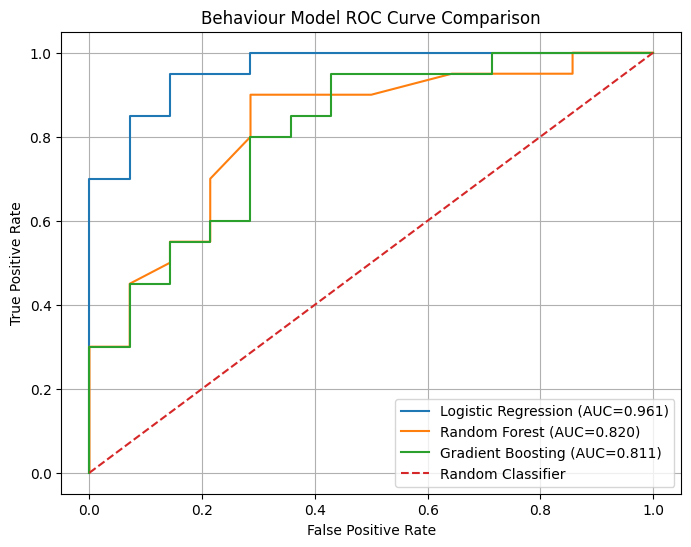

In [16]:
plt.figure(figsize=(8,6))

for model_name, model in trained_behaviour_models.items():

    y_prob = model.predict_proba(X_beh_val)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_beh_val,
        y_prob
    )

    auc_score = roc_auc_score(
        y_beh_val,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Behaviour Model ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
# compare prediction probabilities of the models 
comparison = pd.DataFrame({
    "actual": y_beh_val
})

for name, model in trained_behaviour_models.items():
    comparison[name] = model.predict_proba(X_beh_val)[:, 1]

comparison.head(20)

,actual,Logistic Regression,Random Forest,Gradient Boosting
0,0,0.499783,0.46,0.147094
1,0,0.397992,0.46,0.901657
2,1,0.630891,0.70,0.962093
3,1,0.678268,0.63,0.880129
4,0,0.450266,0.65,0.953555
5,0,0.322472,0.76,0.582584
6,1,0.806114,0.60,0.924723
7,1,0.670923,0.46,0.812201
8,1,0.901752,1.00,0.981382
9,0,0.459953,0.62,0.868652


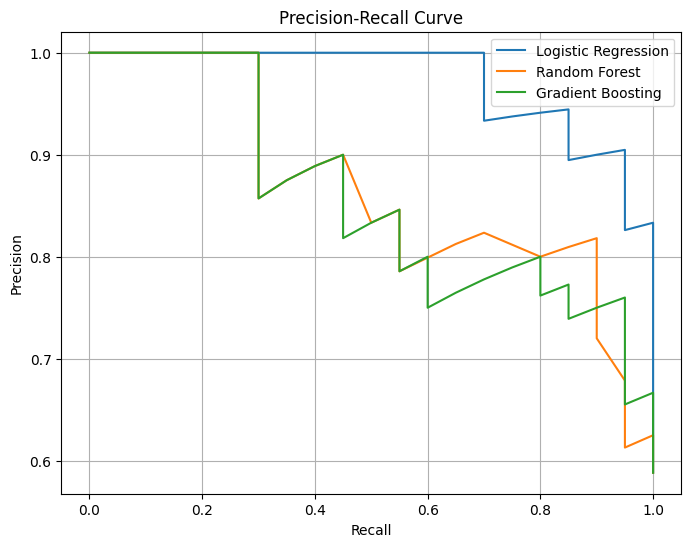

In [19]:
# precision-recall curve 
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name, model in trained_behaviour_models.items():

    y_prob = model.predict_proba(X_beh_val)[:,1]

    precision, recall, _ = precision_recall_curve(
        y_beh_val,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# feature importance 
lr = trained_behaviour_models["Logistic Regression"]

importance = pd.DataFrame({
    "feature": X_beh_train.columns,
    "coefficient": lr.coef_[0]
})

importance["abs_coef"] = importance["coefficient"].abs()

importance.sort_values(
    "abs_coef",
    ascending=False
)

,feature,coefficient,abs_coef
8,top_material_type_Lecture Material,0.496999,0.496999
6,top_material_type_Assignment,-0.388964,0.388964
7,top_material_type_Course Page,-0.204517,0.204517
9,top_material_type_No Activity,0.096885,0.096885
5,avg_events_per_active_day,0.059560,0.059560
1,active_days,-0.046915,0.046915
2,unique_materials,-0.025234,0.025234
4,weekend_events,0.017552,0.017552
0,total_events,-0.001456,0.001456
3,after_hours_events,0.000374,0.000374


In [21]:
# validation predictions table 
best_model = trained_behaviour_models["Logistic Regression"]

predictions = pd.DataFrame({
    "actual": y_beh_val,
    "predicted": best_model.predict(X_beh_val),
    "risk_probability":
        best_model.predict_proba(X_beh_val)[:,1]
})

predictions.sort_values(
    "risk_probability",
    ascending=False
).head(20)

,actual,predicted,risk_probability
8,1,1,0.901752
20,1,1,0.873722
29,1,1,0.851317
6,1,1,0.806114
22,1,1,0.795963
23,1,1,0.792879
10,1,1,0.769742
33,1,1,0.747675
13,1,1,0.740015
32,1,1,0.706996


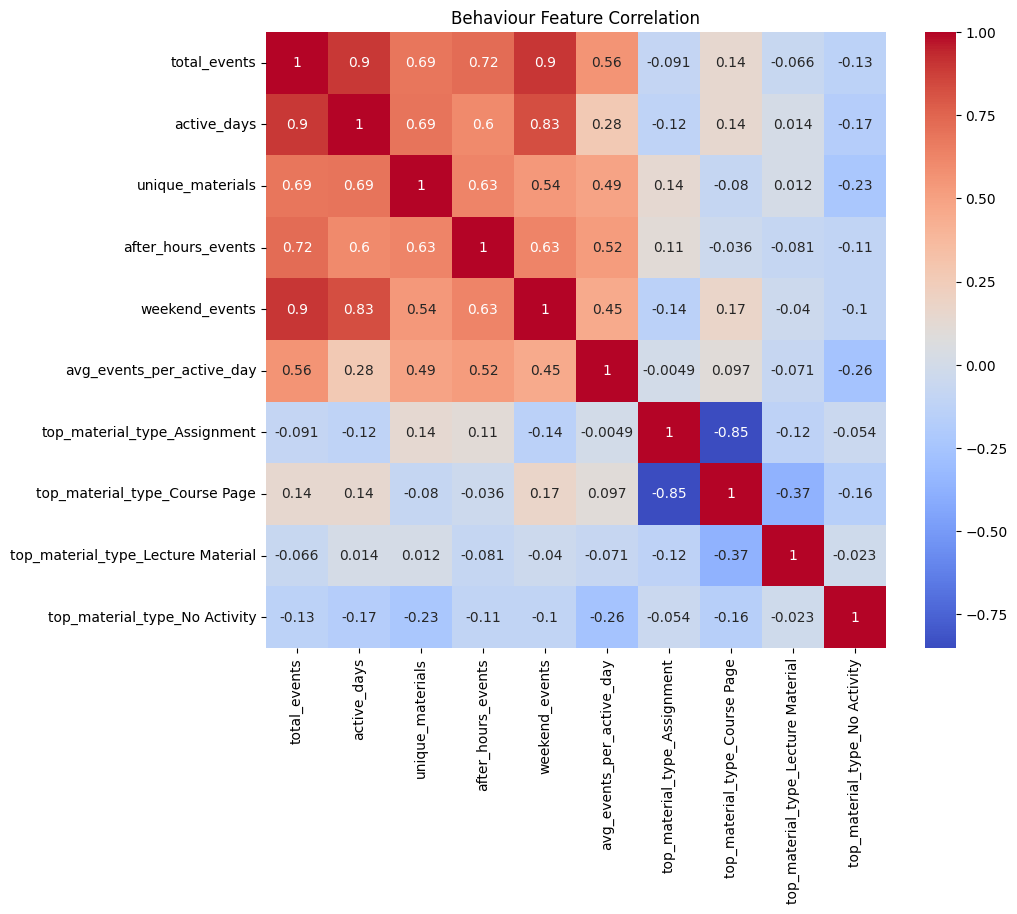

In [22]:
# feature correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    X_beh_train.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Behaviour Feature Correlation")

plt.show()

In [23]:
lr = trained_behaviour_models["Logistic Regression"]

coef_df = pd.DataFrame({
    "feature": X_beh_train.columns,
    "coefficient": lr.coef_[0]
})

coef_df.sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient
8,top_material_type_Lecture Material,0.496999
9,top_material_type_No Activity,0.096885
5,avg_events_per_active_day,0.059560
4,weekend_events,0.017552
3,after_hours_events,0.000374
0,total_events,-0.001456
2,unique_materials,-0.025234
1,active_days,-0.046915
7,top_material_type_Course Page,-0.204517
6,top_material_type_Assignment,-0.388964


In [24]:
coef_df.sort_values(
    "coefficient",
    ascending=True
)

,feature,coefficient
6,top_material_type_Assignment,-0.388964
7,top_material_type_Course Page,-0.204517
1,active_days,-0.046915
2,unique_materials,-0.025234
0,total_events,-0.001456
3,after_hours_events,0.000374
4,weekend_events,0.017552
5,avg_events_per_active_day,0.059560
9,top_material_type_No Activity,0.096885
8,top_material_type_Lecture Material,0.496999


In [25]:
X_beh_train["top_material_type_No Activity"].sum()

np.int64(1)

In [27]:
# rebuild snapshot from existing behaviour data
snapshot = pd.concat([X_beh_train, X_beh_val], ignore_index=True).copy()
snapshot["risk_label"] = pd.concat([y_beh_train, y_beh_val], ignore_index=True).values

# recover single top_material_type from one-hot columns
material_cols = [c for c in snapshot.columns if c.startswith("top_material_type_")]
snapshot["top_material_type"] = (
    snapshot[material_cols]
    .idxmax(axis=1)
    .str.replace("top_material_type_", "", regex=False)
)

pd.crosstab(
    snapshot["top_material_type"],
    snapshot["risk_label"],
    normalize="index"
)

risk_label,0,1
top_material_type,,
Assignment,0.500000,0.500000
Course Page,0.380435,0.619565
Lecture Material,0.285714,0.714286
No Activity,0.000000,1.000000


In [28]:
# find students with No Activity as top material type
no_activity_students = snapshot[snapshot["top_material_type"] == "No Activity"]

print(f"Total students with No Activity: {len(no_activity_students)}")
no_activity_students[["total_events", "active_days", "unique_materials", "risk_label", "top_material_type"]]

Total students with No Activity: 2


,total_events,active_days,unique_materials,risk_label,top_material_type
43,0,0,0,1,No Activity
107,0,0,0,1,No Activity


In [29]:
snapshot["top_material_type"].value_counts()

top_material_type
Course Page         92
Assignment          32
Lecture Material     7
No Activity          2
Name: count, dtype: int64

### Experiment 2: Hyperparameter tuning 
best model from experiment 1 and test and compare parameters

## SELECTION FOR ACADEMIC MODEL 

### Experiment 1: Baseline Models Comparison 
1. 
2. 
3. 

### Experiment 2: Hyperparameter tuning 

## ENSEMBLE 
### Experiment 1: combine the winners and test weighted ensemble

### Experiment 2: combine the winners and test Stacking 

## FINAL SELECTION and Save